# CNN-Based Malaria Parasite Recognition in Human Blood Smear Images


### Setup — Colab (Team / TA) or Local

**Running on Colab (recommended for GPU):**
1. Notebook toolbar → **Select Kernel → Colab** → sign in
2. Set **Hardware accelerator = GPU** (T4 if available)
3. Run cells top to bottom — repo and data download automatically

**Running locally (VS Code):**
- Just run cells top to bottom — setup detects local mode automatically


In [1]:
!nvidia-smi

Tue Mar 24 15:49:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
os.listdir('/content/drive/MyDrive/raw')

['miracle9to9', 'malaria', 'iml_malaria']

In [ ]:
import sys, os, torch
from pathlib import Path

try:
    import google.colab
    from google.colab import drive
    drive.mount("/content/drive")

    if not os.path.exists("/content/COMP-472"):
        os.system("git clone -q https://github.com/iamBolu/COMP-472 /content/COMP-472")
    DRIVE_PROJECT_ROOT = "/content/COMP-472"
    os.system("pip install -q -r /content/COMP-472/requirements.txt")

    # Data lives on Google Drive — MyDrive/COMP 472/Project/data/raw
    DATA_ROOT = Path("/content/drive/MyDrive/COMP 472/Project/data/raw")
    IN_COLAB  = True
except ImportError:
    DRIVE_PROJECT_ROOT = str(Path(os.getcwd()).parent) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
    DATA_ROOT = Path(DRIVE_PROJECT_ROOT) / "data" / "raw"
    IN_COLAB  = False

sys.path.insert(0, DRIVE_PROJECT_ROOT)
os.chdir(DRIVE_PROJECT_ROOT)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Runtime : {'Google Colab' if IN_COLAB else 'VS Code (local)'}")
print(f"Device  : {device} {'← GPU ready' if device.type == 'cuda' else '← no GPU detected'}")
print(f"Code dir: {DRIVE_PROJECT_ROOT}")
print(f"Data dir: {DATA_ROOT}")
print(f"Data exists: {DATA_ROOT.exists()}")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

---
## Member 1: Data Visualization & Reporting

### Phase A (do **first**, in parallel with Member 2)
- Bar chart: class distribution per dataset
- Image grid: random samples per class
- Summary table: dataset sizes, class counts, imbalance
- **Define plotting functions:**
  1. `plot_training_curves(history, title)` — expects a `history` dict with keys: `"train_loss"`, `"val_loss"`, `"train_acc"`, `"val_acc"` (all lists, one value per epoch)
  2. `plot_confusion_matrix(labels, preds, class_names, title)` — expects `labels` and `preds` as numpy arrays, `class_names` as a list
  3. `print_classification_report(labels, preds, class_names)` — expects `labels` and `preds` as numpy arrays, `class_names` as a list

### Phase B (do **last**, after Members 3, 4, 5 finish training)
- For each model/dataset, call the plotting functions above using the results provided by Members 3, 4, 5.

---

### **IMPORTANT: Output Format Contract for Members 3, 4, 5**

To ensure compatibility, all training results **must** be provided in the following format:

#### For each architecture (ResNet-18, VGG-16, MobileNet-V2) and each dataset:
```python
# Example for ResNet-18 (Member 3)
resnet_history = {}  # resnet_history["malaria"] = history dict (see below)
resnet_labels  = {}  # resnet_labels["malaria"]  = numpy array (test split)
resnet_preds   = {}  # resnet_preds["malaria"]   = numpy array (test split)

# Example for VGG-16 (Member 4)
vgg_history = {}
vgg_labels  = {}
vgg_preds   = {}

# Example for MobileNet-V2 (Member 5)
mobilenet_history = {}
mobilenet_labels  = {}
mobilenet_preds   = {}
```

#### The `history` dict **must** have:
```python
history = {
    "train_loss": [...],  # float per epoch
    "val_loss":   [...],
    "train_acc":  [...],  # float 0–1 per epoch
    "val_acc":    [...],
}
```

#### For Transfer Learning (Member 5, one dataset only):
```python
tl_freeze_history,  tl_freeze_labels,  tl_freeze_preds   = {...}, {...}, {...}
tl_finetune_history, tl_finetune_labels, tl_finetune_preds = {...}, {...}, {...}
```
- All dicts are keyed by dataset name (e.g. `"malaria"`)
- All arrays are numpy arrays (test split only)

**Member 1 will only accept results in this format.**

---

### Example usage in Member 1 Phase B
```python
# For each model/dataset:
plot_training_curves(resnet_history["malaria"], "ResNet-18 Malaria")
plot_confusion_matrix(resnet_labels["malaria"], resnet_preds["malaria"], class_names, "ResNet-18 Malaria Confusion Matrix")
print_classification_report(resnet_labels["malaria"], resnet_preds["malaria"], class_names)
# ...repeat for VGG-16, MobileNet-V2, TL runs
```
---


In [11]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [12]:
DATASETS = {
    "malaria": os.path.join(DATA_ROOT, "malaria"),
    "iml_malaria": os.path.join(DATA_ROOT, "iml_malaria"),
    "miracle9to9": os.path.join(DATA_ROOT, "miracle9to9"),
}

for name, path in DATASETS.items():
    print(name, "->", path, "exists:", os.path.exists(path))

malaria -> /content/drive/MyDrive/raw/malaria exists: True
iml_malaria -> /content/drive/MyDrive/raw/iml_malaria exists: True
miracle9to9 -> /content/drive/MyDrive/raw/miracle9to9 exists: True


In [13]:
for name, path in DATASETS.items():
    print(f"\n{name}")
    print(os.listdir(path)[:20])


malaria
['test', 'train', 'val']

iml_malaria
['test', 'val', 'train']

miracle9to9
['train', 'test', 'val']


In [14]:
for dataset_name, dataset_path in DATASETS.items():
    print(f"\n{dataset_name}")
    for split in ["train", "val", "test"]:
        split_path = os.path.join(dataset_path, split)
        print(split, "->", os.listdir(split_path))
        


malaria
train -> ['gametocyte', 'trophozoite', 'ring', 'schizont']
val -> ['gametocyte', 'trophozoite', 'schizont', 'ring']
test -> ['gametocyte', 'trophozoite', 'ring', 'schizont']

iml_malaria
train -> ['ring', 'schizont', 'gametocyte', 'trophozoite']
val -> ['gametocyte', 'trophozoite', 'ring', 'schizont']
test -> ['schizont', 'gametocyte', 'ring', 'trophozoite']

miracle9to9
train -> ['Parasitized', 'Uninfected']
val -> ['Parasitized', 'Uninfected']
test -> ['Parasitized', 'Uninfected']


In [15]:
def count_images_in_split(split_path):
    counts = {}
    for class_name in sorted(os.listdir(split_path)):
        class_path = os.path.join(split_path, class_name)
        if os.path.isdir(class_path):
            counts[class_name] = len([
                f for f in os.listdir(class_path)
                if os.path.isfile(os.path.join(class_path, f))
            ])
    return counts

In [16]:
def count_images_in_split(split_path):
    counts = {}
    for class_name in sorted(os.listdir(split_path)):
        class_path = os.path.join(split_path, class_name)
        if os.path.isdir(class_path):
            counts[class_name] = len([
                f for f in os.listdir(class_path)
                if os.path.isfile(os.path.join(class_path, f))
            ])
    return counts

In [17]:
for dataset_name, dataset_path in DATASETS.items():
    print(f"\n{dataset_name}")
    for split in ["train", "val", "test"]:
        split_path = os.path.join(dataset_path, split)
        counts = count_images_in_split(split_path)
        print(split, "->", counts)


malaria
train -> {'gametocyte': 0, 'ring': 0, 'schizont': 0, 'trophozoite': 0}
val -> {'gametocyte': 0, 'ring': 0, 'schizont': 0, 'trophozoite': 0}
test -> {'gametocyte': 0, 'ring': 0, 'schizont': 0, 'trophozoite': 0}

iml_malaria
train -> {'gametocyte': 0, 'ring': 0, 'schizont': 0, 'trophozoite': 0}
val -> {'gametocyte': 0, 'ring': 0, 'schizont': 0, 'trophozoite': 0}
test -> {'gametocyte': 0, 'ring': 0, 'schizont': 0, 'trophozoite': 0}

miracle9to9
train -> {'Parasitized': 0, 'Uninfected': 0}
val -> {'Parasitized': 0, 'Uninfected': 0}
test -> {'Parasitized': 0, 'Uninfected': 0}


In [18]:
example_path = os.path.join(DATASETS["malaria"], "train", "gametocyte")
print(os.listdir(example_path)[:20])

[]


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
print(os.path.exists("/content/drive/MyDrive/raw"))
print(os.listdir("/content/drive/MyDrive/raw"))

True
['miracle9to9', 'malaria', 'iml_malaria']


In [5]:
import os
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import os
print(os.path.exists("/content/drive/MyDrive"))

True


In [7]:
import os
print(os.listdir("/content/drive/MyDrive")[:50])

['lab1_report_coen317.pdf', 'SOEN 341 - CODE IMMIGRANT', 'COEN 390.gdoc', 'PROJECT DOCUMENTS.gdoc', 'CODING', '2025 resume.pdf', 'Copy of Income Budget NW FIRE Spreadsheet.gsheet', 'Untitled document (17).gdoc', 'Leetcode.gdoc', 'JOB APPLICATION TRACKER.gsheet', 'Best Flight Deals.gsheet', 'Cheap Flight Tracker .gsheet', 'Untitled form.gform', 'COEN 346 LAB 1.gdoc', 'LABORATORY REPORT ELEC 372 LAB 1 .gdoc', 'COEN 346 LAB2.gdoc', 'Untitled document (16).gdoc', 'Untitled document (15).gdoc', 'suspended means the process was moved to the disk.gsheet', 'Matlab assignment 1 elec 342.gdoc', 'COMP 353 assignment 1.gdoc', 'PHASE 2 DELIVERABLES FOR BLOCKCHAIN.gdoc', 'VALET SYSTEM IDEA.gdoc', 'Untitled document (14).gdoc', 'Q1).gdoc', 'ELEC 372 LAB 2 REPORT.gdoc', 'ELEC 372 PROFESSOR EXPLANATION.gdoc', 'ELEC 372 NOTE SUMMARIES FOR EXAM  .gdoc', 'COEN 346 ASSIGNMENT 3.gdoc', 'Untitled document (13).gdoc', 'Programming2 Assignment.gdoc', 'Untitled document (12).gdoc', 'Untitled document (11).gdoc'

In [8]:
import os

matches = []
for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for d in dirs:
        name = d.lower()
        if "malaria" in name or "dataset" in name or "cell" in name:
            matches.append(os.path.join(root, d))

print("Found", len(matches), "matches")
for m in matches[:50]:
    print(m)

Found 2 matches
/content/drive/MyDrive/raw/malaria
/content/drive/MyDrive/raw/iml_malaria


In [9]:
import os
print(os.listdir("/content/drive/MyDrive/raw"))

['miracle9to9', 'malaria', 'iml_malaria']


In [10]:
import os

DATA_ROOT = "/content/drive/MyDrive/raw"

DATASETS = {
    "miracle9to9": os.path.join(DATA_ROOT, "miracle9to9"),
    "malaria": os.path.join(DATA_ROOT, "malaria"),
    "iml_malaria": os.path.join(DATA_ROOT, "iml_malaria"),
}

print(DATASETS)

{'miracle9to9': '/content/drive/MyDrive/raw/miracle9to9', 'malaria': '/content/drive/MyDrive/raw/malaria', 'iml_malaria': '/content/drive/MyDrive/raw/iml_malaria'}


In [11]:
print(os.listdir(DATASETS["malaria"]))

['test', 'train', 'val']


In [12]:
print(os.listdir(os.path.join(DATASETS["malaria"], "train")))

['gametocyte', 'trophozoite', 'ring', 'schizont']


In [13]:
example_path = os.path.join(DATASETS["malaria"], "train", "gametocyte")
print("Path:", example_path)
print("Exists:", os.path.exists(example_path))
print("Contents:", os.listdir(example_path))

Path: /content/drive/MyDrive/raw/malaria/train/gametocyte
Exists: True
Contents: []


In [14]:
for root, dirs, files in os.walk(example_path):
    print("ROOT:", root)
    print("DIRS:", dirs[:10])
    print("FILES:", files[:10])
    print("-" * 40)

ROOT: /content/drive/MyDrive/raw/malaria/train/gametocyte
DIRS: []
FILES: []
----------------------------------------


In [15]:
for split in ["train", "val", "test"]:
    split_path = os.path.join(DATASETS["malaria"], split)
    print(f"\n--- {split.upper()} ---")
    for cls in os.listdir(split_path):
        class_path = os.path.join(split_path, cls)
        if os.path.isdir(class_path):
            print(cls, "->", len(os.listdir(class_path)))


--- TRAIN ---
gametocyte -> 0
trophozoite -> 0
ring -> 0
schizont -> 0

--- VAL ---
gametocyte -> 0
trophozoite -> 0
schizont -> 0
ring -> 0

--- TEST ---
gametocyte -> 0
trophozoite -> 0
ring -> 0
schizont -> 0


In [19]:
import os
print(os.listdir("/content/drive/MyDrive/COMP 472/project/data/raw"))

['malaria', 'miracle9to9', 'iml_malaria']


In [20]:
import os

DATA_ROOT = "/content/drive/MyDrive/COMP 472/project/data/raw"

DATASETS = {
    "malaria": os.path.join(DATA_ROOT, "malaria"),
    "miracle9to9": os.path.join(DATA_ROOT, "miracle9to9"),
    "iml_malaria": os.path.join(DATA_ROOT, "iml_malaria"),
}

print(DATASETS)

{'malaria': '/content/drive/MyDrive/COMP 472/project/data/raw/malaria', 'miracle9to9': '/content/drive/MyDrive/COMP 472/project/data/raw/miracle9to9', 'iml_malaria': '/content/drive/MyDrive/COMP 472/project/data/raw/iml_malaria'}


In [21]:
for split in ["train", "val", "test"]:
    split_path = os.path.join(DATASETS["malaria"], split)
    print(f"\n--- {split.upper()} ---")
    for cls in os.listdir(split_path):
        class_path = os.path.join(split_path, cls)
        if os.path.isdir(class_path):
            print(cls, "->", len(os.listdir(class_path)))


--- TRAIN ---
gametocyte -> 49
ring -> 108
trophozoite -> 326
schizont -> 88

--- VAL ---
ring -> 16
gametocyte -> 4
schizont -> 17
trophozoite -> 64

--- TEST ---
gametocyte -> 3
ring -> 45
schizont -> 8
trophozoite -> 38


In [22]:
for name in ["iml_malaria", "miracle9to9"]:
    print(f"\n{name.upper()}")
    for split in ["train", "val", "test"]:
        split_path = os.path.join(DATASETS[name], split)
        print(f"  {split}:")
        for cls in os.listdir(split_path):
            class_path = os.path.join(split_path, cls)
            if os.path.isdir(class_path):
                print(f"    {cls} -> {len(os.listdir(class_path))}")


IML_MALARIA
  train:
    ring -> 41
    gametocyte -> 81
    schizont -> 11
    trophozoite -> 21
  val:
    gametocyte -> 16
    ring -> 8
    schizont -> 2
    trophozoite -> 4
  test:
    gametocyte -> 13
    ring -> 7
    schizont -> 2
    trophozoite -> 3

MIRACLE9TO9
  train:
    Parasitized -> 11713
    Uninfected -> 11712
  val:
    Parasitized -> 2066
    Uninfected -> 2067
  test:
    Uninfected -> 7880
    Parasitized -> 7952


/content/drive/MyDrive/COMP 472/project/data/raw/malaria/train/gametocyte/5a043d69-f435-46d4-8691-395c1602a76a.png
Size: (1600, 1200) Mode: RGB


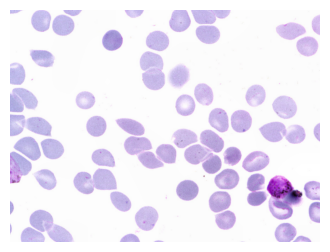

/content/drive/MyDrive/COMP 472/project/data/raw/iml_malaria/train/gametocyte/PA171826.JPG
Size: (1280, 960) Mode: RGB


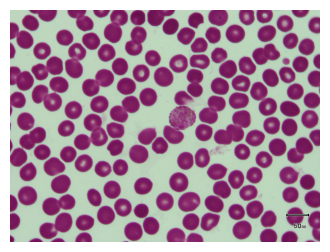

/content/drive/MyDrive/COMP 472/project/data/raw/miracle9to9/train/Parasitized/train__Parasitized__C176P137NThinF_IMG_20151201_122811_cell_166.png
Size: (127, 118) Mode: RGB


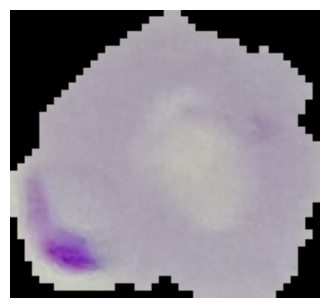

In [23]:
from PIL import Image
import matplotlib.pyplot as plt

sample_paths = [
    os.path.join(DATASETS["malaria"], "train", "gametocyte", os.listdir(os.path.join(DATASETS["malaria"], "train", "gametocyte"))[0]),
    os.path.join(DATASETS["iml_malaria"], "train", "gametocyte", os.listdir(os.path.join(DATASETS["iml_malaria"], "train", "gametocyte"))[0]),
    os.path.join(DATASETS["miracle9to9"], "train", "Parasitized", os.listdir(os.path.join(DATASETS["miracle9to9"], "train", "Parasitized"))[0]),
]

for path in sample_paths:
    img = Image.open(path)
    print(path)
    print("Size:", img.size, "Mode:", img.mode)
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [24]:
for name in DATASETS:
    exts = {}
    for root, dirs, files in os.walk(DATASETS[name]):
        for f in files:
            ext = os.path.splitext(f)[1].lower()
            exts[ext] = exts.get(ext, 0) + 1
    print(f"\n{name}:")
    print(exts)


malaria:
{'': 2, '.jpg': 94, '.png': 672}

miracle9to9:
{'': 4, '.png': 43390}

iml_malaria:
{'': 1, '.jpg': 209}


In [25]:
for name in DATASETS:
    print(f"\n{name}:")
    for root, dirs, files in os.walk(DATASETS[name]):
        for f in files:
            if os.path.splitext(f)[1] == "":
                print(os.path.join(root, f))


malaria:
/content/drive/MyDrive/COMP 472/project/data/raw/malaria/.DS_Store
/content/drive/MyDrive/COMP 472/project/data/raw/malaria/val/.DS_Store

miracle9to9:
/content/drive/MyDrive/COMP 472/project/data/raw/miracle9to9/.DS_Store
/content/drive/MyDrive/COMP 472/project/data/raw/miracle9to9/train/.DS_Store
/content/drive/MyDrive/COMP 472/project/data/raw/miracle9to9/test/.DS_Store
/content/drive/MyDrive/COMP 472/project/data/raw/miracle9to9/val/.DS_Store

iml_malaria:
/content/drive/MyDrive/COMP 472/project/data/raw/iml_malaria/.DS_Store


In [26]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png"}

for name in DATASETS:
    print(f"\n{name}:")
    for split in ["train", "val", "test"]:
        split_path = os.path.join(DATASETS[name], split)
        print(f"  {split}:")
        for cls in os.listdir(split_path):
            class_path = os.path.join(split_path, cls)
            if os.path.isdir(class_path):
                count = sum(
                    1 for f in os.listdir(class_path)
                    if os.path.isfile(os.path.join(class_path, f))
                    and os.path.splitext(f)[1].lower() in IMAGE_EXTS
                )
                print(f"    {cls} -> {count}")


malaria:
  train:
    gametocyte -> 49
    ring -> 108
    trophozoite -> 326
    schizont -> 88
  val:
    ring -> 16
    gametocyte -> 4
    schizont -> 17
    trophozoite -> 64
  test:
    gametocyte -> 3
    ring -> 45
    schizont -> 8
    trophozoite -> 38

miracle9to9:
  train:
    Parasitized -> 11713
    Uninfected -> 11712
  val:
    Parasitized -> 2066
    Uninfected -> 2067
  test:
    Uninfected -> 7880
    Parasitized -> 7952

iml_malaria:
  train:
    ring -> 41
    gametocyte -> 81
    schizont -> 11
    trophozoite -> 21
  val:
    gametocyte -> 16
    ring -> 8
    schizont -> 2
    trophozoite -> 4
  test:
    gametocyte -> 13
    ring -> 7
    schizont -> 2
    trophozoite -> 3


In [27]:
for split in ["train", "val", "test"]:
    split_path = os.path.join(DATASETS["iml_malaria"], split)
    print(f"\n--- {split.upper()} ---")
    for cls in os.listdir(split_path):
        class_path = os.path.join(split_path, cls)
        if os.path.isdir(class_path):
            count = sum(
                1 for f in os.listdir(class_path)
                if os.path.isfile(os.path.join(class_path, f))
                and os.path.splitext(f)[1].lower() in IMAGE_EXTS
            )
            print(cls, "->", count)


--- TRAIN ---
ring -> 41
gametocyte -> 81
schizont -> 11
trophozoite -> 21

--- VAL ---
gametocyte -> 16
ring -> 8
schizont -> 2
trophozoite -> 4

--- TEST ---
gametocyte -> 13
ring -> 7
schizont -> 2
trophozoite -> 3


In [28]:
for split in ["train", "val", "test"]:
    split_path = os.path.join(DATASETS["miracle9to9"], split)
    print(f"\n--- {split.upper()} ---")
    for cls in os.listdir(split_path):
        class_path = os.path.join(split_path, cls)
        if os.path.isdir(class_path):
            count = sum(
                1 for f in os.listdir(class_path)
                if os.path.isfile(os.path.join(class_path, f))
                and os.path.splitext(f)[1].lower() in IMAGE_EXTS
            )
            print(cls, "->", count)


--- TRAIN ---
Parasitized -> 11713
Uninfected -> 11712

--- VAL ---
Parasitized -> 2066
Uninfected -> 2067

--- TEST ---
Uninfected -> 7880
Parasitized -> 7952


In [29]:
from PIL import Image

for name in DATASETS:
    widths, heights = [], []

    for root, dirs, files in os.walk(DATASETS[name]):
        for f in files:
            if os.path.splitext(f)[1].lower() in IMAGE_EXTS:
                path = os.path.join(root, f)
                try:
                    with Image.open(path) as img:
                        w, h = img.size
                        widths.append(w)
                        heights.append(h)
                except Exception as e:
                    print("Could not open:", path, e)

    print(f"\n{name}:")
    print("Total images:", len(widths))
    print("Min size:", (min(widths), min(heights)))
    print("Max size:", (max(widths), max(heights)))
    print("Unique widths (sample):", sorted(set(widths))[:10])
    print("Unique heights (sample):", sorted(set(heights))[:10])


malaria:
Total images: 766
Min size: (1600, 1200)
Max size: (1944, 1383)
Unique widths (sample): [1600, 1944]
Unique heights (sample): [1200, 1383]


KeyboardInterrupt: 

In [30]:
from PIL import Image
import random
import os

IMAGE_EXTS = {".jpg", ".jpeg", ".png"}

for name in DATASETS:
    all_paths = []

    for root, dirs, files in os.walk(DATASETS[name]):
        for f in files:
            if os.path.splitext(f)[1].lower() in IMAGE_EXTS:
                all_paths.append(os.path.join(root, f))

    sample_paths = random.sample(all_paths, min(200, len(all_paths)))

    widths, heights = [], []
    for path in sample_paths:
        with Image.open(path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)

    print(f"\n{name}:")
    print("Sampled images:", len(sample_paths))
    print("Min size:", (min(widths), min(heights)))
    print("Max size:", (max(widths), max(heights)))
    print("Unique widths:", sorted(set(widths))[:10])
    print("Unique heights:", sorted(set(heights))[:10])


malaria:
Sampled images: 200
Min size: (1600, 1200)
Max size: (1944, 1383)
Unique widths: [1600, 1944]
Unique heights: [1200, 1383]

miracle9to9:
Sampled images: 200
Min size: (79, 67)
Max size: (211, 238)
Unique widths: [79, 91, 94, 97, 100, 103, 106, 109, 112, 115]
Unique heights: [67, 79, 88, 91, 97, 100, 103, 106, 109, 112]

iml_malaria:
Sampled images: 200
Min size: (1280, 960)
Max size: (1280, 960)
Unique widths: [1280]
Unique heights: [960]


In [31]:
summary_rows = [
    ["malaria", "train", "gametocyte", 49],
    ["malaria", "train", "ring", 108],
    ["malaria", "train", "trophozoite", 326],
    ["malaria", "train", "schizont", 88],
    ["malaria", "val", "gametocyte", 4],
    ["malaria", "val", "ring", 16],
    ["malaria", "val", "trophozoite", 64],
    ["malaria", "val", "schizont", 17],
    ["malaria", "test", "gametocyte", 3],
    ["malaria", "test", "ring", 45],
    ["malaria", "test", "trophozoite", 38],
    ["malaria", "test", "schizont", 8],

    ["iml_malaria", "train", "gametocyte", 81],
    ["iml_malaria", "train", "ring", 41],
    ["iml_malaria", "train", "trophozoite", 21],
    ["iml_malaria", "train", "schizont", 11],
    ["iml_malaria", "val", "gametocyte", 16],
    ["iml_malaria", "val", "ring", 8],
    ["iml_malaria", "val", "trophozoite", 4],
    ["iml_malaria", "val", "schizont", 2],
    ["iml_malaria", "test", "gametocyte", 13],
    ["iml_malaria", "test", "ring", 7],
    ["iml_malaria", "test", "trophozoite", 3],
    ["iml_malaria", "test", "schizont", 2],

    ["miracle9to9", "train", "Parasitized", 11713],
    ["miracle9to9", "train", "Uninfected", 11712],
    ["miracle9to9", "val", "Parasitized", 2066],
    ["miracle9to9", "val", "Uninfected", 2067],
    ["miracle9to9", "test", "Parasitized", 7952],
    ["miracle9to9", "test", "Uninfected", 7880],
]

summary_df = pd.DataFrame(summary_rows, columns=["dataset", "split", "class", "count"])
summary_df

NameError: name 'pd' is not defined

In [32]:
import pandas as pd

In [33]:
summary_rows = [
    ["malaria", "train", "gametocyte", 49],
    ["malaria", "train", "ring", 108],
    ["malaria", "train", "trophozoite", 326],
    ["malaria", "train", "schizont", 88],
    ["malaria", "val", "gametocyte", 4],
    ["malaria", "val", "ring", 16],
    ["malaria", "val", "trophozoite", 64],
    ["malaria", "val", "schizont", 17],
    ["malaria", "test", "gametocyte", 3],
    ["malaria", "test", "ring", 45],
    ["malaria", "test", "trophozoite", 38],
    ["malaria", "test", "schizont", 8],

    ["iml_malaria", "train", "gametocyte", 81],
    ["iml_malaria", "train", "ring", 41],
    ["iml_malaria", "train", "trophozoite", 21],
    ["iml_malaria", "train", "schizont", 11],
    ["iml_malaria", "val", "gametocyte", 16],
    ["iml_malaria", "val", "ring", 8],
    ["iml_malaria", "val", "trophozoite", 4],
    ["iml_malaria", "val", "schizont", 2],
    ["iml_malaria", "test", "gametocyte", 13],
    ["iml_malaria", "test", "ring", 7],
    ["iml_malaria", "test", "trophozoite", 3],
    ["iml_malaria", "test", "schizont", 2],

    ["miracle9to9", "train", "Parasitized", 11713],
    ["miracle9to9", "train", "Uninfected", 11712],
    ["miracle9to9", "val", "Parasitized", 2066],
    ["miracle9to9", "val", "Uninfected", 2067],
    ["miracle9to9", "test", "Parasitized", 7952],
    ["miracle9to9", "test", "Uninfected", 7880],
]

summary_df = pd.DataFrame(summary_rows, columns=["dataset", "split", "class", "count"])
summary_df

,dataset,split,class,count
0,malaria,train,gametocyte,49
1,malaria,train,ring,108
2,malaria,train,trophozoite,326
3,malaria,train,schizont,88
4,malaria,val,gametocyte,4
5,malaria,val,ring,16
6,malaria,val,trophozoite,64
7,malaria,val,schizont,17
8,malaria,test,gametocyte,3
9,malaria,test,ring,45


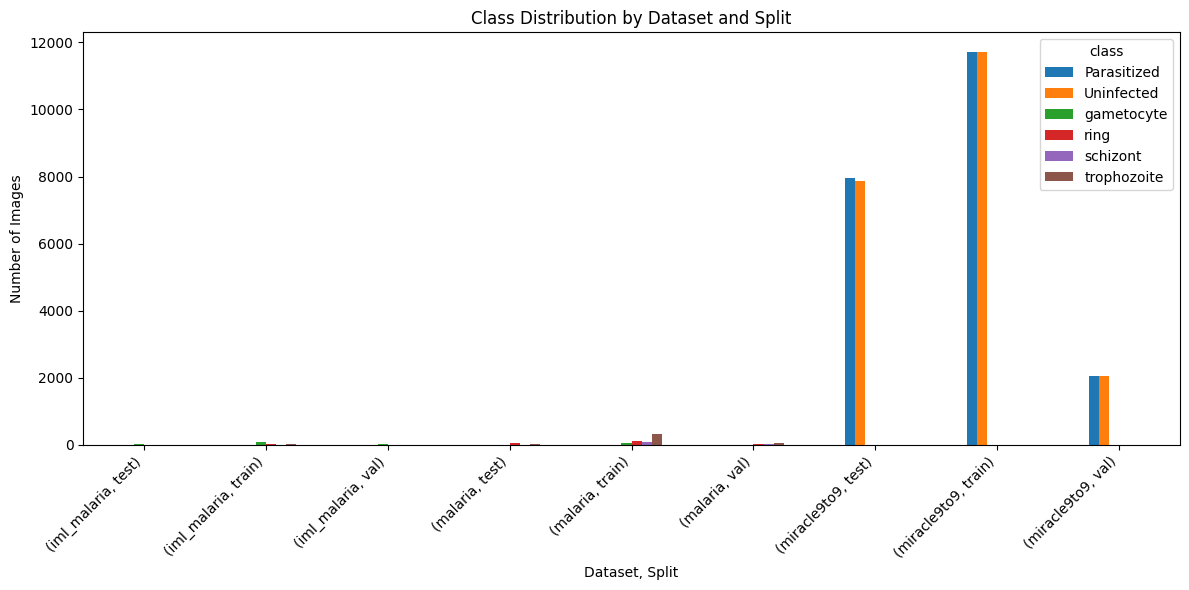

In [34]:
import matplotlib.pyplot as plt

pivot_df = summary_df.pivot_table(
    index=["dataset", "split"],
    columns="class",
    values="count",
    fill_value=0
)

pivot_df.plot(kind="bar", figsize=(12, 6))
plt.title("Class Distribution by Dataset and Split")
plt.ylabel("Number of Images")
plt.xlabel("Dataset, Split")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [35]:
dataset_totals = summary_df.groupby("dataset")["count"].sum().reset_index()
dataset_totals.columns = ["dataset", "total_images"]

split_totals = summary_df.groupby(["dataset", "split"])["count"].sum().reset_index()
split_totals.columns = ["dataset", "split", "total_images"]

print("Dataset totals:")
print(dataset_totals)

print("\nSplit totals:")
print(split_totals)

Dataset totals:
       dataset  total_images
0  iml_malaria           209
1      malaria           766
2  miracle9to9         43390

Split totals:
       dataset  split  total_images
0  iml_malaria   test            25
1  iml_malaria  train           154
2  iml_malaria    val            30
3      malaria   test            94
4      malaria  train           571
5      malaria    val           101
6  miracle9to9   test         15832
7  miracle9to9  train         23425
8  miracle9to9    val          4133


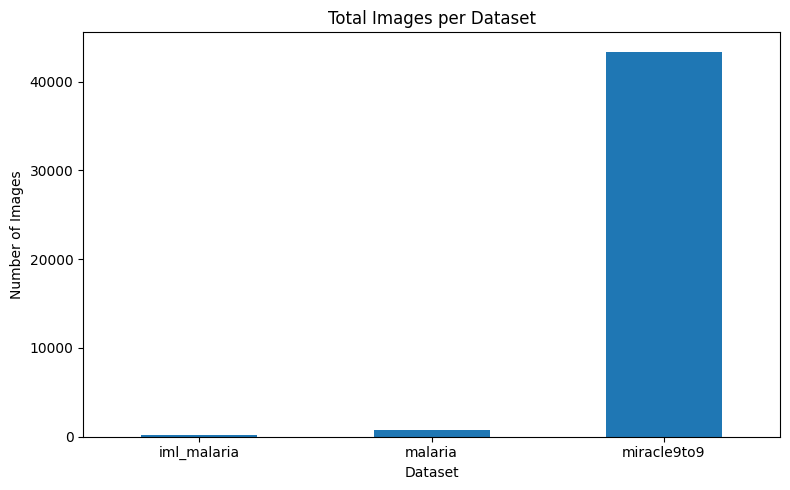

In [36]:
dataset_totals.plot(x="dataset", y="total_images", kind="bar", legend=False, figsize=(8, 5))
plt.title("Total Images per Dataset")
plt.ylabel("Number of Images")
plt.xlabel("Dataset")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

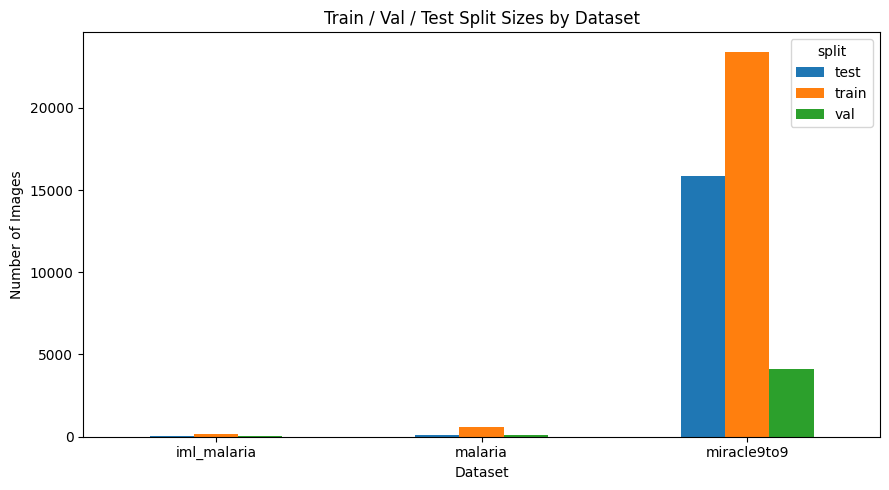

In [37]:
split_pivot = split_totals.pivot(index="dataset", columns="split", values="total_images")

split_pivot.plot(kind="bar", figsize=(9, 5))
plt.title("Train / Val / Test Split Sizes by Dataset")
plt.ylabel("Number of Images")
plt.xlabel("Dataset")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [38]:
size_rows = [
    ["malaria", "sampled", 200, "(1600, 1200)", "(1944, 1383)", "[1600, 1944]", "[1200, 1383]"],
    ["miracle9to9", "sampled", 200, "(79, 67)", "(211, 238)", "many", "many"],
    ["iml_malaria", "sampled", 200, "(1280, 960)", "(1280, 960)", "[1280]", "[960]"],
]

size_df = pd.DataFrame(
    size_rows,
    columns=[
        "dataset",
        "method",
        "sample_size",
        "min_size",
        "max_size",
        "unique_widths",
        "unique_heights"
    ]
)

size_df

,dataset,method,sample_size,min_size,max_size,unique_widths,unique_heights
0,malaria,sampled,200,"(1600, 1200)","(1944, 1383)","[1600, 1944]","[1200, 1383]"
1,miracle9to9,sampled,200,"(79, 67)","(211, 238)",many,many
2,iml_malaria,sampled,200,"(1280, 960)","(1280, 960)",[1280],[960]


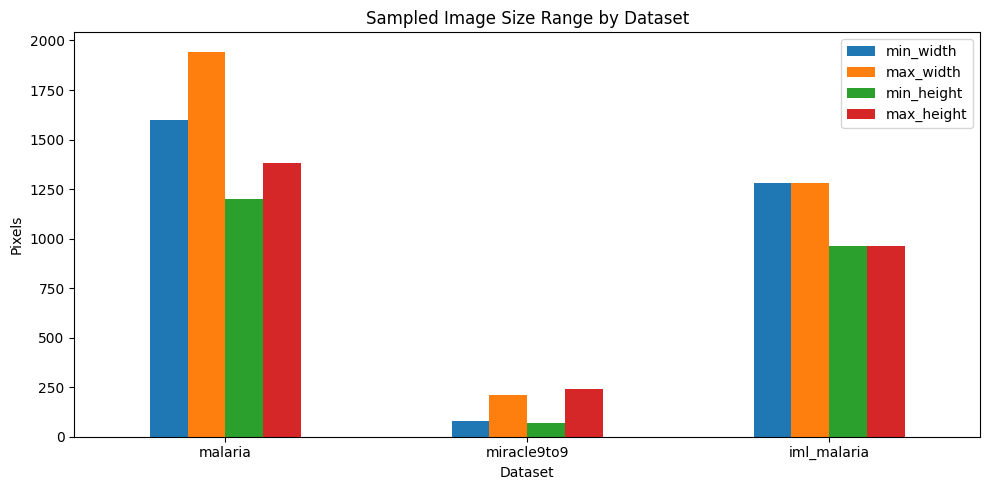

In [39]:
size_plot_df = pd.DataFrame({
    "dataset": ["malaria", "miracle9to9", "iml_malaria"],
    "min_width": [1600, 79, 1280],
    "max_width": [1944, 211, 1280],
    "min_height": [1200, 67, 960],
    "max_height": [1383, 238, 960],
})

size_plot_df.set_index("dataset")[["min_width", "max_width", "min_height", "max_height"]].plot(
    kind="bar", figsize=(10, 5)
)
plt.title("Sampled Image Size Range by Dataset")
plt.ylabel("Pixels")
plt.xlabel("Dataset")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [40]:
def plot_class_distribution(df, dataset_name):
    subset = df[df["dataset"] == dataset_name]
    pivot = subset.pivot(index="split", columns="class", values="count").fillna(0)

    pivot.plot(kind="bar", figsize=(8, 5))
    plt.title(f"Class Distribution for {dataset_name}")
    plt.ylabel("Number of Images")
    plt.xlabel("Split")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

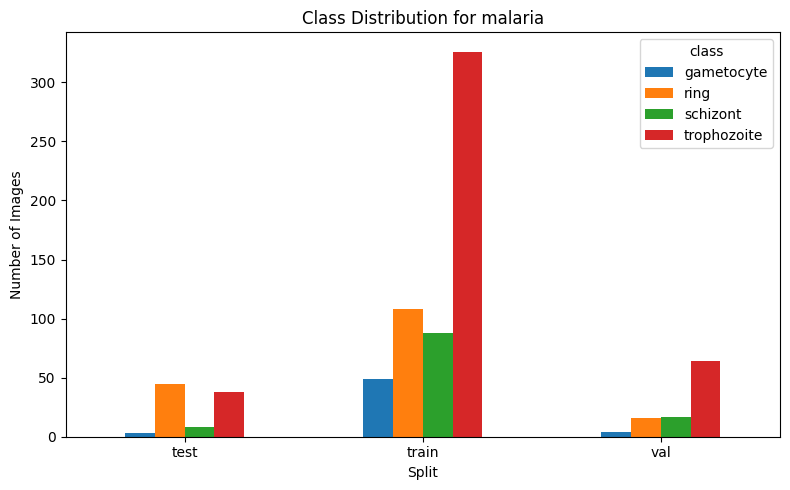

In [41]:
plot_class_distribution(summary_df, "malaria")

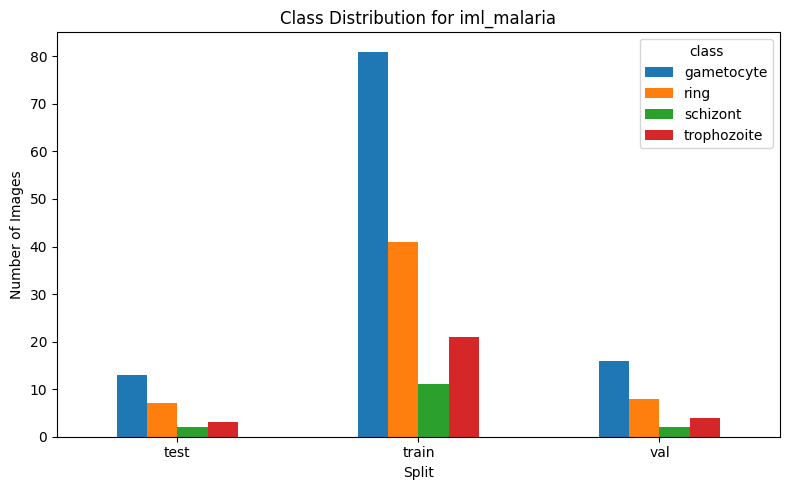

In [42]:
plot_class_distribution(summary_df, "iml_malaria")

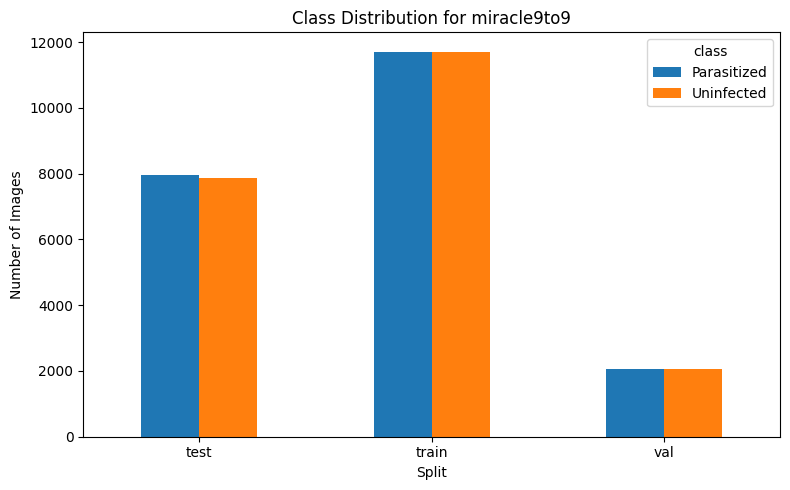

In [43]:
plot_class_distribution(summary_df, "miracle9to9")

In [44]:
def plot_split_totals(split_totals_df, dataset_name):
    subset = split_totals_df[split_totals_df["dataset"] == dataset_name]

    plt.figure(figsize=(6, 4))
    plt.bar(subset["split"], subset["total_images"])
    plt.title(f"Split Sizes for {dataset_name}")
    plt.ylabel("Number of Images")
    plt.xlabel("Split")
    plt.tight_layout()
    plt.show()

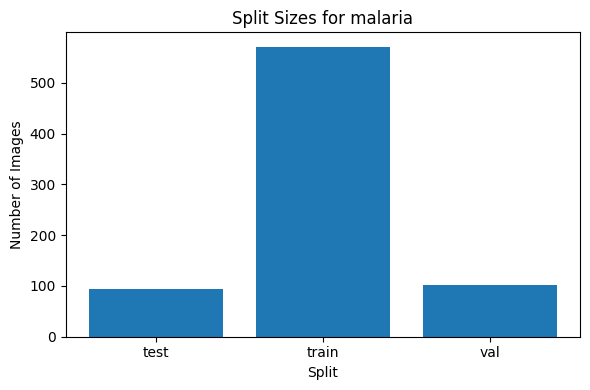

In [45]:
plot_split_totals(split_totals, "malaria")

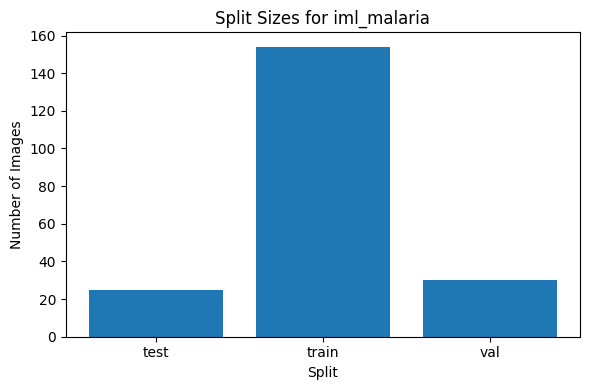

In [46]:
plot_split_totals(split_totals, "iml_malaria")

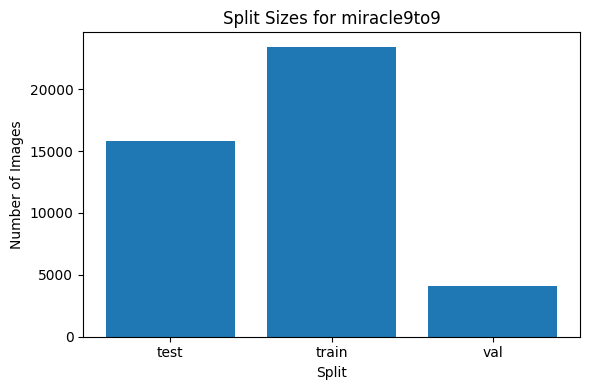

In [47]:
plot_split_totals(split_totals, "miracle9to9")

In [48]:
phase_a_findings = pd.DataFrame([
    ["malaria", 766, "4 classes", "imbalanced", "mixed large sizes", "Contains .jpg and .png; a few .DS_Store files"],
    ["iml_malaria", 209, "4 classes", "highly imbalanced", "fixed at 1280x960 in sample", "Very small dataset; contains .jpg and .DS_Store"],
    ["miracle9to9", 43390, "2 classes", "well balanced", "small variable sizes", "Mostly .png; contains .DS_Store files"]
], columns=[
    "dataset",
    "total_images",
    "class_setup",
    "class_balance",
    "image_size_behavior",
    "notes"
])

phase_a_findings

,dataset,total_images,class_setup,class_balance,image_size_behavior,notes
0,malaria,766,4 classes,imbalanced,mixed large sizes,Contains .jpg and .png; a few .DS_Store files
1,iml_malaria,209,4 classes,highly imbalanced,fixed at 1280x960 in sample,Very small dataset; contains .jpg and .DS_Store
2,miracle9to9,43390,2 classes,well balanced,small variable sizes,Mostly .png; contains .DS_Store files


In [49]:
print("=== DATASET TOTALS ===")
display(dataset_totals)

print("\n=== SPLIT TOTALS ===")
display(split_totals)

print("\n=== PHASE A FINDINGS ===")
display(phase_a_findings)

print("\n=== IMAGE SIZE SUMMARY ===")
display(size_df)

=== DATASET TOTALS ===


,dataset,total_images
0,iml_malaria,209
1,malaria,766
2,miracle9to9,43390



=== SPLIT TOTALS ===


,dataset,split,total_images
0,iml_malaria,test,25
1,iml_malaria,train,154
2,iml_malaria,val,30
3,malaria,test,94
4,malaria,train,571
5,malaria,val,101
6,miracle9to9,test,15832
7,miracle9to9,train,23425
8,miracle9to9,val,4133



=== PHASE A FINDINGS ===


,dataset,total_images,class_setup,class_balance,image_size_behavior,notes
0,malaria,766,4 classes,imbalanced,mixed large sizes,Contains .jpg and .png; a few .DS_Store files
1,iml_malaria,209,4 classes,highly imbalanced,fixed at 1280x960 in sample,Very small dataset; contains .jpg and .DS_Store
2,miracle9to9,43390,2 classes,well balanced,small variable sizes,Mostly .png; contains .DS_Store files



=== IMAGE SIZE SUMMARY ===


,dataset,method,sample_size,min_size,max_size,unique_widths,unique_heights
0,malaria,sampled,200,"(1600, 1200)","(1944, 1383)","[1600, 1944]","[1200, 1383]"
1,miracle9to9,sampled,200,"(79, 67)","(211, 238)",many,many
2,iml_malaria,sampled,200,"(1280, 960)","(1280, 960)",[1280],[960]


## Member 1 – Phase A Summary

In Phase A, the three malaria datasets were successfully located, loaded, and verified from the project data directory in Google Drive. The folder structure for each dataset was checked to confirm the presence of the expected training, validation, and test splits, as well as the class-specific subfolders. Image counts were computed for each class and split, showing that `miracle9to9` is the largest dataset and is relatively balanced, while `malaria` is smaller and imbalanced, and `iml_malaria` is the smallest and most imbalanced dataset.

Sample images from all three datasets were opened successfully, confirming that the files are readable and correspond to the expected labels. File-type inspection showed that the datasets mainly contain `.png` and `.jpg` images, with a few `.DS_Store` files from macOS that should be ignored during processing. Image-size inspection further showed that `iml_malaria` has consistent dimensions, while `malaria` and especially `miracle9to9` contain more variation in image size.

To support later analysis, summary tables and pre-training visualizations were created, including class-distribution plots, dataset-total plots, split-total plots, and reusable plotting functions. Overall, Phase A confirmed that the datasets are accessible, structurally valid, and ready for later training and evaluation stages.

---
## Member 2: Pipeline Implementation

**Goal:** Data quality checks, common transform policy, and DataLoader creation for all 3 datasets.  
All 9 baseline training runs (ResNet-18, VGG-16, MobileNet-V2 × miracle9to9, orvile, malaria) consume `dataloaders_registry` directly.


### Step 1 - Imports & Constants


In [ ]:
import pandas as pd
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# DATA_ROOT and device are set in cell 3 based on runtime
IMAGE_INPUT_SIZE = 128
BATCH_SIZE       = 32
NUM_WORKERS      = 0
DATASET_NAMES    = ["miracle9to9", "malaria", "iml_malaria"]
IMAGE_EXTENSIONS = {".jpg", ".png"}

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print(f"DATA_ROOT: {DATA_ROOT}")
print(f"Exists:    {DATA_ROOT.exists()}")


### Step 2 - Data Inventory

Scan all images under `data/raw/` and report class distribution and imbalance ratios per dataset/split.
PIL validation is skipped — `broken_files_report.txt` (notebooks/) was generated in a prior run.


In [ ]:
all_image_paths = pd.Series([
    path for path in DATA_ROOT.rglob("*")
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
])

if all_image_paths.empty:
    raise FileNotFoundError(f"No images found under '{DATA_ROOT.resolve()}'. Expected: data/raw/<dataset>/<split>/<class>/image.ext")

valid_images_inventory_df = pd.DataFrame({
    "dataset":   all_image_paths.map(lambda p: p.relative_to(DATA_ROOT).parts[0]),
    "split":     all_image_paths.map(lambda p: p.relative_to(DATA_ROOT).parts[1]),
    "class_raw": all_image_paths.map(lambda p: p.parent.name),
    "filepath":  all_image_paths,
})
print(f"Total images: {len(valid_images_inventory_df)}")

class_distribution_df = (
    valid_images_inventory_df
    .groupby(["dataset", "split", "class_raw"])
    .size()
    .reset_index(name="image_count")
)
print("\nClass distribution:")
print(class_distribution_df.to_string(index=False))

split_totals_df = (
    valid_images_inventory_df
    .groupby(["dataset", "split"])
    .size()
    .reset_index(name="total_images")
)
print("\nSplit totals:")
print(split_totals_df.to_string(index=False))

imbalance_df = (
    class_distribution_df
    .groupby(["dataset", "split"])["image_count"]
    .agg(max_count="max", min_count="min")
    .assign(imbalance_ratio=lambda df: (df["max_count"] / df["min_count"]).round(2))
    .reset_index()
)
print("\nImbalance ratios (max / min class count):")
print(imbalance_df.to_string(index=False))


### Step 3 - Transform Policy

One shared policy for all 9 baseline training runs.  
- `training_transforms` : resize → geometric augmentation → color jitter → normalize  
- `evaluation_transforms` : resize → normalize only (no augmentation on val/test)


In [ ]:
training_transforms = transforms.Compose([
    transforms.Resize((IMAGE_INPUT_SIZE, IMAGE_INPUT_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(90),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

evaluation_transforms = transforms.Compose([
    transforms.Resize((IMAGE_INPUT_SIZE, IMAGE_INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("training_transforms :")
print(training_transforms)
print("\nevaluation_transforms :")
print(evaluation_transforms)


### Step 4 - MalariaDataset

Custom `Dataset` that works for all three datasets.  
Accepts a pre-filtered `split_inventory_df` slice from `valid_images_inventory_df` (Step 2), so only validated images are ever loaded.  
Handles `orvile`'s duplicate training folders (`"gametocyte 2"` → `"gametocyte"`) by stripping the trailing numeric suffix via vectorized regex on class folder names.


In [ ]:
class MalariaDataset(Dataset):
    def __init__(self, split_inventory_df, transform=None):
        normalized_class_names = split_inventory_df["class_raw"].str.replace(r"\s+\d+$", "", regex=True)

        unique_classes   = sorted(normalized_class_names.unique())
        class_to_index   = {class_name: index for index, class_name in enumerate(unique_classes)}

        self.image_paths  = split_inventory_df["filepath"].to_numpy()
        self.labels       = normalized_class_names.map(class_to_index).to_numpy()
        self.class_names  = unique_classes
        self.class_to_idx = class_to_index
        self.transform    = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image = Image.open(self.image_paths[index]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, int(self.labels[index])


### Step 5 - Datasets & DataLoaders

`datasets_registry[dataset_name][split]` → `MalariaDataset`  
`dataloaders_registry[dataset_name][split]` → `DataLoader` ready for training  

All 9 scratch models and 2 transfer learning models consume `dataloaders_registry`.


In [ ]:
SPLIT_TRANSFORMS = {"train": training_transforms, "val": evaluation_transforms, "test": evaluation_transforms}

datasets_registry = {
    dataset_name: {
        split: MalariaDataset(
            valid_images_inventory_df[
                (valid_images_inventory_df["dataset"] == dataset_name) &
                (valid_images_inventory_df["split"]   == split)
            ].reset_index(drop=True),
            transform=split_transform,
        )
        for split, split_transform in SPLIT_TRANSFORMS.items()
    }
    for dataset_name in DATASET_NAMES
}

dataloaders_registry = {
    dataset_name: {
        split: DataLoader(
            dataset,
            batch_size  = BATCH_SIZE,
            shuffle     = (split == "train"),
            num_workers = NUM_WORKERS,
            pin_memory  = torch.cuda.is_available(),
            drop_last   = (split == "train"),
        )
        for split, dataset in split_datasets.items()
        if len(dataset) > 0
    }
    for dataset_name, split_datasets in datasets_registry.items()
}

for dataset_name, split_datasets in datasets_registry.items():
    for split_name, dataset in split_datasets.items():
        if len(dataset) == 0:
            print(f"{dataset_name:15s} | {split_name:5s} | SKIPPED since 0 valid images")
            continue
        num_batches = len(dataloaders_registry[dataset_name][split_name])
        print(f"{dataset_name:15s} | {split_name:5s} | {len(dataset):5d} images | {num_batches:3d} batches | classes: {dataset.class_names}")


---
## Member 2: New Coding Tasks

### New Coding Tasks (TO DO)
1. **Reproducibility** — `torch.manual_seed(42)`, `torch.backends.cudnn.deterministic = True`, `torch.backends.cudnn.benchmark = False`.
2. **`build_model(arch, num_classes)`** — returns ResNet-18, VGG-16, or MobileNet-V2 with `weights=None` and final layer replaced. Called by all members.
3. **`count_parameters(model)`** — returns total trainable parameter count. Print a comparison table for all 3 architectures (`num_classes=4`).
4. **`train_one_epoch(model, loader, criterion, optimizer, device)`** — one forward + backward pass; returns average loss and accuracy.
5. **`evaluate(model, loader, criterion, device)`** — one forward-only pass; returns average loss and accuracy.

### Hints
- Final layer per arch: `resnet.fc`, `vgg.classifier[6]`, `mobilenet.classifier[1]` → **Lab_Tutorial_Week_8 (1).ipynb, line 152**
- `count_parameters` → **Lab_Tutorial_Week_8 (1).ipynb, line 54**
- `train_one_epoch` → **Lab_Tutorial_Week_9.ipynb, line 1000**
- `evaluate` → **Lab_Tutorial_Week_9.ipynb, line 1042**
- Use `torchvision.models` with `weights=None`. No TensorFlow / Keras.

### Requirements Alignment
> *"The architectures should vary in terms of complexity (number of layers and learnable parameters)."* — Project Requirements

The parameter count table directly justifies the complexity difference between ResNet-18, VGG-16, and MobileNet-V2.

### Tasks for Final Report & Video
- **Methodology > Models**: parameter count table; one-line description per architecture.


---
## Member 3: Training Loop + ResNet-18

### Uses from Member 2 *(must be defined before running this section)*
- `build_model(arch, num_classes)` — instantiate ResNet-18 with `weights=None`
- `train_one_epoch(model, loader, criterion, optimizer, device)`
- `evaluate(model, loader, criterion, device)`

### New Coding Tasks (TO DO)
1. **`collect_predictions(model, loader, device)`** — returns `(labels, preds)` as **numpy arrays** over the full loader.
2. **`fit(model, train_loader, val_loader, optimizer, criterion, device, epochs, checkpoint_path)`** — calls `train_one_epoch` + `evaluate` each epoch, saves best-val checkpoint, returns a `history` dict.
3. **Train ResNet-18 × 3** (miracle9to9, malaria, iml_malaria): `lr=0.001`, Adam, CrossEntropyLoss, `epochs=10`. Save checkpoints to `Path(DRIVE_PROJECT_ROOT) / "checkpoints"`.

### Output contract for Member 1 Phase B
`fit()` must return a dict with **exactly** these keys:
```python
history = {
    "train_loss": [...],  # float per epoch
    "val_loss":   [...],
    "train_acc":  [...],  # float 0–1 per epoch
    "val_acc":    [...],
}
```
After training, run `collect_predictions` on the **test** split and store results — Members 4 & 5 follow the same pattern:
```python
resnet_history = {}  # resnet_history["miracle9to9"] = history dict
resnet_labels  = {}  # resnet_labels["miracle9to9"]  = numpy array
resnet_preds   = {}  # resnet_preds["miracle9to9"]   = numpy array
```
Member 1's `plot_training_curves(history, title)`, `plot_confusion_matrix(labels, preds, class_names, title)`, and `print_classification_report(labels, preds, class_names)` will consume these directly.

### Hints
- `collect_predictions` → **Lab_Tutorial_Week_9.ipynb, line 1064**
- `fit` with history + checkpointing → **Lab_Tutorial_Week_9.ipynb, line 1136**
- `num_classes = len(datasets_registry[dataset_name]["train"].class_names)`
- No TensorFlow / Keras.

### Requirements Alignment
> *"train 9 different models... for fair comparison, all models should be trained under the same conditions (same hyperparameters)."* — Project Requirements

### Tasks for Final Report & Video
- Report val and test accuracy for each of the 3 ResNet-18 runs.


---
## Member 4: VGG-16 + Optimization

### Uses from Member 2 & 3 *(must be defined before running this section)*
- `build_model("vgg16", num_classes)` — from Member 2
- `train_one_epoch`, `evaluate` — from Member 2
- `fit(model, train_loader, val_loader, optimizer, criterion, device, epochs, checkpoint_path)` — from Member 3
- `collect_predictions(model, loader, device)` — from Member 3

### New Coding Tasks (TO DO)
1. **Train VGG-16 × 3** (miracle9to9, malaria, iml_malaria): `lr=0.001`, Adam, CrossEntropyLoss, `epochs=10`.
2. **LR sweep** — on one dataset, train VGG-16 with `lr ∈ {0.01, 0.001, 0.0001}`. Log val accuracy per LR. Pick the best and explain why.

### Output contract for Member 1 Phase B
Follow the **same storage pattern** as Member 3:
```python
vgg_history = {}  # vgg_history["miracle9to9"] = history dict with train_loss/val_loss/train_acc/val_acc
vgg_labels  = {}  # vgg_labels["miracle9to9"]  = numpy array (test split)
vgg_preds   = {}  # vgg_preds["miracle9to9"]   = numpy array
```
Member 1's `plot_training_curves`, `plot_confusion_matrix`, and `print_classification_report` will consume these directly.

### Hints
- `build_model("vgg16", num_classes)` → **Lab_Tutorial_Week_8 (1).ipynb, line 152**
- LR sweep loop → **Lab_Tutorial_Week_9.ipynb, line ~1136**
- No TensorFlow / Keras.

### Requirements Alignment
> *"Each team should choose at least one of the 9 models trained from scratch and attempt to optimize it through hyperparameter tuning... only from: learning rate, batch size, and loss function."* — Project Requirements

### Tasks for Final Report & Video
- Report val and test accuracy for each of the 3 VGG-16 runs.
- Table: LR → val accuracy; justify the best LR choice.


---
## Member 5: MobileNet-V2 + Transfer Learning + T-SNE

### Uses from Member 2 & 3 *(must be defined before running this section)*
- `build_model("mobilenet_v2", num_classes)` — from Member 2
- `train_one_epoch`, `evaluate` — from Member 2
- `fit(model, train_loader, val_loader, optimizer, criterion, device, epochs, checkpoint_path)` — from Member 3
- `collect_predictions(model, loader, device)` — from Member 3

### New Coding Tasks (TO DO)
1. **Train MobileNet-V2 × 3** (miracle9to9, malaria, iml_malaria): `lr=0.001`, Adam, CrossEntropyLoss, `epochs=10`.
2. **TL Run 1** (pick one dataset) — pretrained weights (`weights="IMAGENET1K_V1"`), freeze backbone, train head only for 10 epochs.
3. **TL Run 2** (same dataset) — unfreeze full network, fine-tune for 10 epochs from the frozen checkpoint.
4. **T-SNE** — for ≥4 models: replace classifier with `nn.Identity()`, extract test-set embeddings, `sklearn.manifold.TSNE(n_components=2)`, scatter plot coloured by class label.
5. **Final comparison table** — val accuracy, test accuracy, macro-F1 for all 11 models as a sorted DataFrame.

### Output contract for Member 1 Phase B
Follow the **same storage pattern** as Members 3 & 4:
```python
mobilenet_history  = {}  # mobilenet_history["miracle9to9"]  = history dict with train_loss/val_loss/train_acc/val_acc
mobilenet_labels   = {}  # mobilenet_labels["miracle9to9"]   = numpy array (test split)
mobilenet_preds    = {}  # mobilenet_preds["miracle9to9"]    = numpy array

# TL runs — store under the chosen dataset name with a descriptive key
tl_freeze_history,  tl_freeze_labels,  tl_freeze_preds   = {...}, {...}, {...}
tl_finetune_history, tl_finetune_labels, tl_finetune_preds = {...}, {...}, {...}
```
Member 1's `plot_training_curves`, `plot_confusion_matrix`, `print_classification_report` will consume all of these.

### Hints
- `build_model("mobilenet_v2", num_classes)` → **Lab_Tutorial_Week_8 (1).ipynb, line 152**
- `build_transfer_model()` (freeze backbone) → **Lab_Tutorial_Week_9.ipynb, line 7004**
- `fit_transfer_model()` → **Lab_Tutorial_Week_9.ipynb, line 7035**
- F1: `sklearn.metrics.f1_score(labels, preds, average="macro")`
- No TensorFlow / Keras.

### Requirements Alignment
> *"2 additional models using Transfer Learning (any 2 combinations of dataset+architecture)."* — Project Requirements  
> *"Use TSNE or Grad-CAM to visualize the performance of at least 4 different models."* — Project Requirements

### Tasks for Final Report & Video
- Compare scratch vs TL-freeze vs TL-fine-tune — table + discussion.
- T-SNE scatter plots in **Results & Discussion**.
- **Conclusion** — best model per dataset, key findings, limitations.
